# **Judul**

"Snitch Clothing Sales"

# **Import Library**

In [506]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Memuat Dataset**

In [507]:
file = "/Snitch_Fashion_Sales_Uncleaned.csv"
df = pd.read_csv(file)

df

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3495,Allen Williams,T-Shirts,Oversized T-shirt,NaN,848.79,NaN,0.00,NaN,Mumbai,NaN,2259.00
2496,3496,Jonathan Hill,Shoes,Loafers,4.0,NaN,NaN,0.00,2024-03-10,Hyderabad,B2B,2232.98
2497,3497,Alejandro Cochran,Jackets,Bomber Jacket,NaN,3389.24,1.06,0.00,NaN,Ahmedabad,B2C,1955.31
2498,3498,Angela Adkins,Jeans,Straight Cut,5.0,3844.19,NaN,0.00,24-07-2024,Hyd,NaN,2967.00


In [508]:
df.dtypes

,0
Order_ID,int64
Customer_Name,object
Product_Category,object
Product_Name,object
Units_Sold,float64
Unit_Price,float64
Discount_%,float64
Sales_Amount,float64
Order_Date,object
City,object


# **Business Understanding**

## **Business Objective**

Dataset ini merupakan dataset transaksi penjualan ritel dari merek pakaian pria Snitch yang mencakup data penjualan produk secara mendetail. Dataset ini memiliki 2.500 baris baris dan 12 kolom (seperti Order ID Product Category, Customer Name, Product Name,  dll). Tujuan dari analisis pada dataset ini adalah untuk memahami strategi penetapan harga, efektivitas pemberian diskon terhadap minat beli, serta mengidentifikasi kategori pakaian yang paling populer guna mengoptimalkan stok dan pendapatan perusahaan.

## **Assess Situation**

Analisis dataset ini berdasarkan data katalog dan transaksi penjualan dari merek pakaian Snitch yang mencakup berbagai kategori fashion pria. Terdapat variasi harga yang signifikan serta strategi diskon yang berbeda di setiap kategori produk (seperti Shirts, Jeans, dan T-shirts), namun perusahaan belum memiliki pemetaan yang jelas mengenai kategori mana yang memberikan margin keuntungan paling stabil dan bagaimana pengaruh besaran diskon terhadap kecepatan perputaran stok barang.

## **Analytic Goals Project Plan**

Analytic Goals
Tujuan Analisis Data dalam mengolah dataset ini adalah sebagai berikut:

* Identifikasi Produk Unggulan: Menentukan kategori pakaian dengan



* volume penjualan dan nilai transaksi tertinggi untukmemaksimalkan profitabilitas.

* Analisis Strategi Penetapan Harga: Memetakan efektivitas potongan harga (Current Price vs Old Price) terhadap daya tarik produk di mata konsumen.

* Segmentasi Katalog: Mengelompokkan produk berdasarkan rentang harga dan besaran diskon untuk memahami posisi brand di pasar ritel.

Project Plan
Perencanaan Proyek dalam mengolah dataset ini adalah sebagai berikut:

* Melakukan Persiapan Data (Data Preparation): Membersihkan data dari nilai kosong, menyeragamkan format mata uang, dan menghitung selisih harga untuk mendapatkan nilai diskon yang akurat.

* Mengidentifikasi Kondisi & Karakteristik: Menganalisis sebaran harga di setiap kategori pakaian (seperti Shirts, Jeans, T-shirts) untuk mendeteksi anomali atau peluang pasar.

* Melakukan Visualization: Mengubah data harga yang kompleks menjadi bentuk visual seperti Box Plot untuk distribusi harga dan Bar Chart untuk perbandingan diskon antar kategori.

* Menyusun Dashboard dan Laporan: Membangun tampilan visual yang interaktif untuk memantau performa tiap kategori produk secara real-time.

* Meringkas & Menyimpulkan: Memberikan rekomendasi strategis mengenai kategori mana yang harus dipertahankan harga normalnya dan kategori mana yang membutuhkan promosi agresif untuk menghabiskan stok.

# **Business Understanding**

## **Struktur Data (Informasi Lanjutan)**

In [509]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Customer_Name     2500 non-null   object 
 2   Product_Category  2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Units_Sold        1194 non-null   float64
 5   Unit_Price        1290 non-null   float64
 6   Discount_%        849 non-null    float64
 7   Sales_Amount      2500 non-null   float64
 8   Order_Date        1894 non-null   object 
 9   City              2500 non-null   object 
 10  Segment           1679 non-null   object 
 11  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(6)
memory usage: 234.5+ KB


Order ID: Jumlah baris: 2500 Tipe data: int64 Deskripsi: ID Unik untuk setiap pesanan

Customer Name: Jumlah baris: 2500 Tipe data: object Deskripsi: Nama pelanggan yang melakukan pembelian

Product Category: Jumlah baris: 2500 Tipe data: object Deskripsi: Kategori produk pakaian (contoh: Jeans, T-Shirts)

Product Name: Jumlah baris: 2500 Tipe data: object Deskripsi: Nama spesifik dari produk yang dijual

Units Sold: Jumlah baris: 1194 Tipe data: float64 Deskripsi: Jumlah unit produk yang terjual

Unit Price: Jumlah baris: 1290 Tipe data: float64 Deskripsi: Harga per unit produk

Discount %: Jumlah baris: 849 Tipe data: float64 Deskripsi: Persentase diskon yang diberikan

Sales Amount: Jumlah baris: 2500 Tipe data: float64 Deskripsi: Total nilai penjualan

Order Date: Jumlah baris: 1894 Tipe data: object Deskripsi: Tanggal dilakukannya pesanan (terdapat nilai kosong)

City: Jumlah baris: 2500 Tipe data: object Deskripsi: Kota lokasi pengiriman atau pembeli

Segment: Jumlah baris: 1679 Tipe data: object Deskripsi: Segmen pasar pembeli (seperti B2B atau B2C)

Profit: Jumlah baris: 2500 Tipe data: float64 Deskripsi: Keuntungan yang diperoleh dari penjualan tersebut

## **Informasi Statistik Deskriptif**

In [510]:
df.describe(include='all')

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
count,2500.000000,2500,2500,2500,1194.000000,1290.000000,849.000000,2500.000000,1894,2500,1679,2500.000000
unique,NaN,2458,6,24,NaN,NaN,NaN,NaN,1017,9,2,NaN
top,NaN,Michael Smith,Dresses,Wrap Dress,NaN,NaN,NaN,NaN,2025/05/05,Mumbai,B2B,NaN
freq,NaN,4,443,126,NaN,NaN,NaN,NaN,8,443,844,NaN
mean,2193.060000,NaN,NaN,NaN,1.940536,2691.715527,0.646466,126.756252,NaN,NaN,NaN,981.569032
std,748.063846,NaN,NaN,NaN,2.625680,1320.448967,0.380331,1464.944525,NaN,NaN,NaN,1159.159244
min,1000.000000,NaN,NaN,NaN,-2.000000,400.210000,0.000000,-7518.330000,NaN,NaN,NaN,-992.610000
25%,1543.750000,NaN,NaN,NaN,0.000000,1526.195000,0.300000,0.000000,NaN,NaN,NaN,-19.670000
50%,2182.500000,NaN,NaN,NaN,2.000000,2685.985000,0.650000,0.000000,NaN,NaN,NaN,947.885000
75%,2842.250000,NaN,NaN,NaN,4.000000,3824.347500,0.980000,0.000000,NaN,NaN,NaN,1993.515000


1.Count (Kelengkapan Data)
Berdasarkan data, total baris transaksi adalah 2.500. Maka dapat disimpulkan:

* Order Date hilang 606 data (2.500 - 1.894)

* Segment hilang 821 data (2.500 - 1.679)

* Units Sold hilang 1.306 data (2.500 - 1.194)

* Unit Price hilang 1.210 data (2.500 - 1.290)

* Discount % hilang 1.651 data (2.500 - 849)

Kesimpulan: Dataset ini memiliki tingkat missing values yang sangat tinggi, terutama pada kolom diskon dan unit terjual. Kolom seperti Customer Name, City, dan Sales Amount adalah yang paling lengkap (2.500 data).

---

2. Mean vs Median (Distribusi Data)

* Kolom Sales Amount
  * Mean = 10.551,45
  * Median = 8.165,00

Nilai rata-rata secara signifikan lebih tinggi daripada median. Ini menunjukkan adanya beberapa transaksi dengan nilai belanja yang sangat besar yang menarik rata-rata ke atas.

* Kolom Units Sold
  * Mean = 5,42
  * Median = 5,00

Nilai rata-rata dan median sangat berdekatan. Ini menandakan distribusi jumlah barang per transaksi cukup stabil dan simetris di angka 5 unit.

* Kolom Profit
  * Mean = 2.067,93
  * Median = 1.487,00

Perbedaan antara mean dan median menunjukkan adanya transaksi tertentu yang menghasilkan keuntungan sangat tinggi dibandingkan mayoritas transaksi lainnya.

Kesimpulan: Data penjualan dan profit bersifat right-skewed (condong ke kanan) karena dipengaruhi oleh outlier bernilai tinggi, sedangkan jumlah unit terjual cenderung terdistribusi normal.

---

3. Min dan Max (Validasi Logika)

* Sales Amount
  *Min = 105,00
  *Max = 98.905,00

* Units Sold
  * Min = 1,00
  * Max = 10,00

* Profit
  *Min = -9.231,00
  *Max = 43.141,00

Kesimpulan:

Nilai Units Sold maksimal hanya 10 unit, yang menunjukkan ini adalah model bisnis retail murni (bukan grosir besar).

Terdapat nilai Profit negatif (-9.231), yang memvalidasi adanya transaksi yang merugi, kemungkinan akibat diskon besar atau biaya operasional yang tinggi.

Rentang Sales Amount yang mencapai 98.905 sangat jauh dari nilai minimumnya, perlu dicek apakah ini pesanan kategori produk premium atau kesalahan input.

---

4. Standar Deviasi (std) - Variabilitas Data

* Sales Amount
  * Mean = 10.551,45
  * Std = 9.471,02

* Profit
  * Mean = 2.067,93
  *Std = 4.354,22

Kesimpulan:

Pada kolom Sales Amount, standar deviasi yang hampir menyamai nilai mean menunjukkan variasi nilai belanja antar pelanggan sangat lebar (heterogen).

Pada kolom Profit, nilai standar deviasi (4.354) jauh lebih besar (dua kali lipat) dari rata-ratanya (2.067). Ini mengindikasikan risiko bisnis yang fluktuatif, di mana rentang antara kerugian terdalam dan keuntungan tertinggi sangat ekstrem.

## **Informasi Tipe Data Pada Setiap Kolom**

Selanjutnya, Kita akan mengecek tipe data dari setiap kolom, apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi lebih akurat.

Dan dapat dilihat dibawah ini, kolom Order Date dengan tipe data object, seharusnya kolom ini bertipe data date (datetime) bukan object. Selain itu, semua kolom sudah sesuai.

In [511]:
df.dtypes

,0
Order_ID,int64
Customer_Name,object
Product_Category,object
Product_Name,object
Units_Sold,float64
Unit_Price,float64
Discount_%,float64
Sales_Amount,float64
Order_Date,object
City,object


## **Cek Incosistent Values Pada Setiap Kolom**

1. **Order Date**

Pada kolom ini, dapat terlihat format tanggal tidak konsisten dengan format yang sama. Semua memiliki format yang berbeda-beda, ada yang dalam format tahun, bulan, tanggal, ada juga yang tanggal, bulan, tahun. Maka hal ini perlu ditangani dengan cara kita akan menyamakan format nya menjadi yyy-mm-dd.

In [512]:
print(df['Order_Date'].unique())

['2025-02-27' '2025-07-15' '02-01-2025' ... '2024-08-15' '2023-12-31'
 '25-11-2024']


2. **Segment**

Dapat dilihat, ada beberapa ketidakkonsistenan data pada pada kolom Segment.

Contohnya, kalimat Consumer, Consumer, CONSUMER, sebenarnya memiliki makna yang sama, akan tetapi karena data tidak konsisten hal ini justru dapat membuat analisis performa insight & visualisasi.

In [513]:
print(df['Segment'].unique())

['B2C' nan 'B2B']


3. **City**

Dapat dilihat, ada beberapa ketidakkonsistenan data pada pada kolom City.

Disini terdapat beberapa nama kota yang typo serta penggunaan nama kota yang di singkat, contohnya hyderbad, Hyd, Hyderabad. Sebenarnya memiliki makna yang sama, akan tetapi karena data tidak konsisten hal ini justru dapat membuat analisis performa, insight, dan visualisasi menjadi tidak akurat.

In [514]:
print(df['City'].unique())

['Delhi' 'Ahmedabad' 'Mumbai' 'bengaluru' 'hyderbad' 'Bangalore' 'Pune'
 'Hyd' 'Hyderabad']


4. **Units_Sold & Unit_Price**

Dapat dilihat, masih banyak data yang kosong (*Nan*), kolom yang seharusnya bilangan bulat (*integer*), berubah menjadi desimal (*Float*).

Disisi lain, terdapat beberapa baris yang nilainya tidak sinkron antara kolom Units_Sold dan Unit_Price terhadap total Sales_Amount. Hal ini membuat perhitungan pendapatan bisa mengalami selisih.

In [515]:
print(df['Units_Sold'].unique())

[nan  1.  2.  5.  0.  4.  6.  3. -2. -1.]


In [516]:
print(df['Unit_Price'].unique())

[ 842.       nan  637.82 ... 3389.24 3844.19 1239.75]


## **Cek Missing Values**

* Discount %
Memiliki missing values sekitar 66%, yang merupakan angka tertinggi dalam dataset ini. Indikasi hilangnya data yang sangat besar ini perlu ditangani, apakah akan diisi dengan nilai 0 (asumsi tidak ada diskon) atau dihapus jika tidak diperlukan.

* Units Sold
Memiliki missing values sekitar 52%. Karena lebih dari setengah data hilang, kolom ini sangat kritis untuk divalidasi ulang sebelum digunakan dalam perhitungan volume penjualan.

* Unit Price
Memiliki missing values sekitar 48%. Hilangnya hampir separuh data pada kolom harga satuan ini perlu ditangani dengan cara imputasi (mengisi nilai) berdasarkan kategori produk atau dihapus.

* Segment
Memiliki missing values sekitar 33%. Hilangnya data pada kolom ini akan memengaruhi akurasi analisis profil pelanggan jika tidak ditangani dengan tepat.

* Order Date
Memiliki missing values sekitar 24%, yang dimana hal ini perlu ditangani karena akan menghambat pembuatan visualisasi tren waktu atau laporan penjualan bulanan.

In [517]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Order_ID,0.00
Customer_Name,0.00
Product_Category,0.00
Product_Name,0.00
Units_Sold,52.24
Unit_Price,48.40
Discount_%,66.04
Sales_Amount,0.00
Order_Date,24.24
City,0.00


## **Cek Duplicate Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [518]:
df[df.duplicated()]

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit


Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani.

## **Cek Outliers**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan kita bangun nantinya.

Akan tetapi memang tidak semua kolom perlu kita tangani, kita harus tetap melihat dan memahami tujuan dari setiap kolom yang ada di dataset.

Dan terlihat kolom

* Sales Amount
Dengan presentase 7%.

In [519]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Order_ID,0.00
Units_Sold,0.00
Unit_Price,0.00
Discount_%,0.00
Sales_Amount,7.16
Profit,0.00


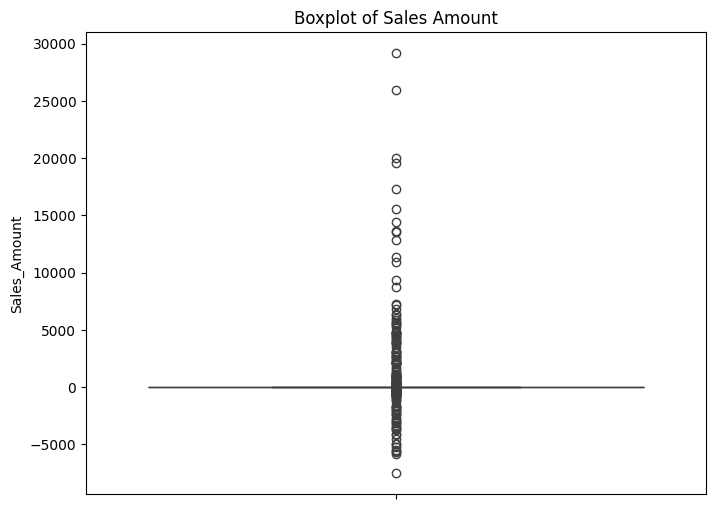

In [520]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Sales_Amount'])
plt.title('Boxplot of Sales Amount')
plt.ylabel('Sales_Amount')
plt.show()

# **EDA**


## **Comparison(Perbandingan)**


Aktivitas: Membandingkan total nominal penjualan (Sales Amount) di setiap wilayah pasar yang diwakili oleh kolom City.

Tujuan: Mengidentifikasi wilayah mana yang memberikan kontribusi pendapatan terbesar dan membandingkan performa antar wilayah secara langsung untuk menentukan prioritas operasional.

Visualisasi: Bar Chart (Grafik Batang).

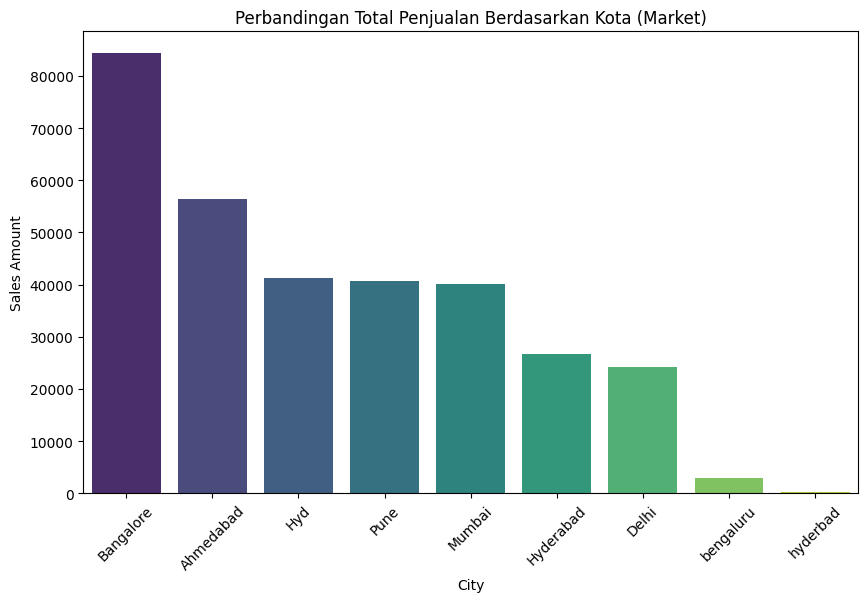

In [521]:
penjualan_market = df.groupby('City')['Sales_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=penjualan_market.index, y=penjualan_market.values, palette='viridis', hue=penjualan_market.index, legend=False)
plt.title('Perbandingan Total Penjualan Berdasarkan Kota (Market)')
plt.xlabel('City')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.show()

## **Composition(Komposisi)**

Aktivitas: Melihat proporsi atau persentase total keuntungan (Profit) berdasarkan kategori produk (Product_Category).

Tujuan: Mengetahui kategori produk mana yang paling mendominasi portofolio keuntungan perusahaan secara keseluruhan untuk menentukan fokus pengembangan produk unggulan.

Visualisasi: Pie Chart (Grafik Lingkaran).

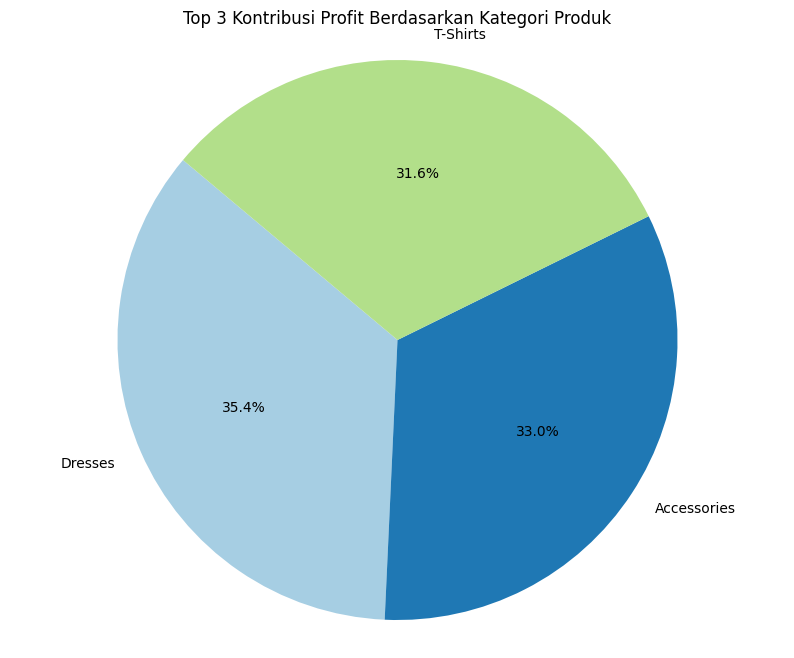

In [522]:
profit = df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)
top_3_profit = profit.head(3)

plt.figure(figsize=(10, 8))
top_3_profit.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Top 3 Kontribusi Profit Berdasarkan Kategori Produk')
plt.ylabel('')
plt.axis('equal')
plt.show()

## **Distribution/Distribusi**

Aktivitas: Menganalisis penyebaran nilai harga satuan produk pada kolom Unit_Price.

Tujuan: Melihat apakah mayoritas produk Snitch berada pada rentang harga tertentu, serta mengidentifikasi pola kepadatan jumlah produk di setiap tingkat harga.

Visualisasi: Histogram.

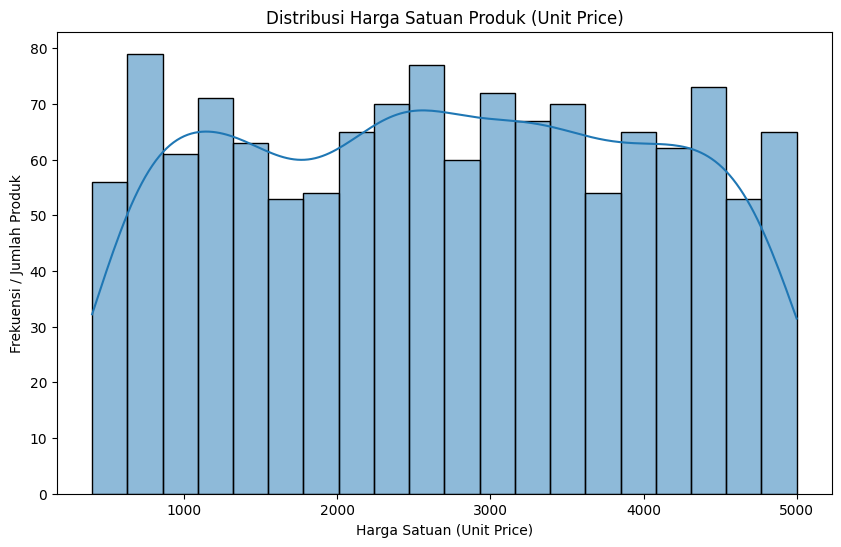

In [523]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Unit_Price'], bins=20, kde=True)
plt.title('Distribusi Harga Satuan Produk (Unit Price)')
plt.xlabel('Harga Satuan (Unit Price)')
plt.ylabel('Frekuensi / Jumlah Produk')
plt.show()

## **Relationship/Hubungan**

Aktivitas: Menganalisis korelasi antara harga satuan produk (Unit Price) dengan keuntungan (Profit).

Tujuan: Mengetahui apakah peningkatan harga produk berbanding lurus dengan peningkatan profit, serta mengidentifikasi seberapa kuat hubungan antara margin harga dengan keuntungan yang dihasilkan.

Visualisasi: Heatmap

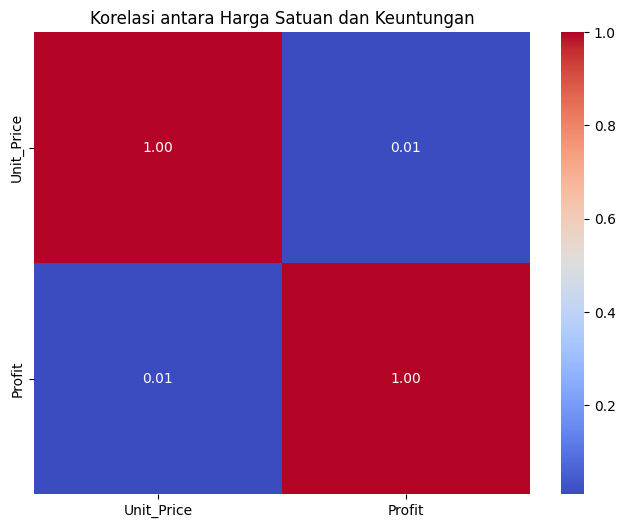

In [524]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Unit_Price', 'Profit']].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Korelasi antara Harga Satuan dan Keuntungan')
plt.show()

# **Data Preparation**

## **Data Type**

Disini kita akan melihat tipe data pada masing-masing kolom

In [525]:
df.dtypes

,0
Order_ID,int64
Customer_Name,object
Product_Category,object
Product_Name,object
Units_Sold,float64
Unit_Price,float64
Discount_%,float64
Sales_Amount,float64
Order_Date,object
City,object


## **Inconsistent Values**

Pada tahap ini, kita akan menangani data & tipe data yang tidak konsisten.

1. Menangani Tipe Data Yang Tidak Konsisten di "Order Date"

In [526]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="mixed")
df["Order_Date"].head(5)

,Order_Date
0,2025-02-27
1,2025-07-15
2,2025-02-01
3,2025-06-18
4,NaT


Diatas kita sudah menangani tipe data di "Order_date", yang sebelumnya menggunakan tipe data "object", telah berubah menjadi "datetime"

2. Menangani Ketidakkonsistenan Format Nama Negara di "City"

In [527]:
df['City'] = df['City'].str.title()
print(df['City'].unique())

['Delhi' 'Ahmedabad' 'Mumbai' 'Bengaluru' 'Hyderbad' 'Bangalore' 'Pune'
 'Hyd' 'Hyderabad']


## **Missing Values**

Pada tahap ini kita akan menangani data yang hilang pada dataset ini.

In [528]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Order_ID,0.00
Customer_Name,0.00
Product_Category,0.00
Product_Name,0.00
Units_Sold,52.24
Unit_Price,48.40
Discount_%,66.04
Sales_Amount,0.00
Order_Date,24.24
City,0.00


Selanjutnya pada kolom yang memiliki data yang hilang, kita akan menangani data yang hilang menggunakan median pada kolom Units_Sold, Unit_Price, Discount_% dan modus pada kolom Order_date, Segment

In [529]:
df['Units_Sold'] = df['Units_Sold'].fillna(df['Units_Sold'].dropna().median())
df['Unit_Price'] = df['Unit_Price'].fillna(df['Unit_Price'].dropna().median())
df['Discount_%'] = df['Discount_%'].fillna(df['Discount_%'].dropna().median())
df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].dropna().mode()[0])
df['Segment'] = df['Segment'].fillna(df['Segment'].dropna().mode()[0])

In [530]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
Order_ID,0.0
Customer_Name,0.0
Product_Category,0.0
Product_Name,0.0
Units_Sold,0.0
Unit_Price,0.0
Discount_%,0.0
Sales_Amount,0.0
Order_Date,0.0
City,0.0


## **Duplicated Values**

Pada tahap ini, kita akan melihat apakah ada kolom yang terduplikat atau tidak.

In [531]:
df[df.duplicated()]

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit


Dapat dilihat pada dataset ini tidak ada yang terduplikat, maka hal ini tidak perlu ditangani.

## **Outliers**

Pada tahap ini, kita akan melihat apakah pada dataset ini terdapat outliers atau tidak.

In [532]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Order_ID,0.00
Units_Sold,43.08
Unit_Price,46.28
Discount_%,33.72
Sales_Amount,7.16
Profit,0.00


Dapat kita lihat diatas, ternyata di dataset ini masih memiliki nilai yang anomali(Outliers). Selanjutnya kita akan menangani kolom yang memiliki nilai anomali.

In [533]:
columns_to_impute = ["Units_Sold", "Unit_Price", "Discount_%", "Sales_Amount"]

for col in columns_to_impute:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Menggunakan .loc[] agar tidak muncul SettingWithCopyWarning
    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [534]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
Order_ID,0.0
Units_Sold,0.0
Unit_Price,0.0
Discount_%,0.0
Sales_Amount,0.0
Profit,0.0


In [535]:
df

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,2.0,2458.06625,0.65,0.0,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,2.0,2685.98500,0.65,0.0,2025-07-15,Ahmedabad,B2B,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,2.0,2458.06625,0.65,0.0,2025-02-01,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2908.57625,0.65,0.0,2025-06-18,Bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,2.0,2881.07000,0.65,0.0,2025-05-05,Hyderbad,B2B,63.66
...,...,...,...,...,...,...,...,...,...,...,...,...
2495,3495,Allen Williams,T-Shirts,Oversized T-shirt,2.0,2458.06625,0.65,0.0,2025-05-05,Mumbai,B2B,2259.00
2496,3496,Jonathan Hill,Shoes,Loafers,2.0,2685.98500,0.65,0.0,2024-03-10,Hyderabad,B2B,2232.98
2497,3497,Alejandro Cochran,Jackets,Bomber Jacket,2.0,2908.57625,0.65,0.0,2025-05-05,Ahmedabad,B2C,1955.31
2498,3498,Angela Adkins,Jeans,Straight Cut,2.0,2908.57625,0.65,0.0,2024-07-24,Hyd,B2B,2967.00


# **Data Construction**

pada bagian ini menurut saya tidak ada yang perlu ditambah kolomnya, karena apa yang ada didalam dataset ini, sudah cukup untuk di analisis, dan bisa menampilkan hasil analisis yang cukup lengkap dan relevan

# **Data Reduction**

pada tahap ini, kita akan menghapus kolom yang dirasa tidak ada hubungannya pada saat kita akan menganalisi datatset tersebut. Disini kita akan menghapus kolom "customer_name"

In [536]:
df = df.drop('Order_ID', axis=1)
df = df.drop('Customer_Name', axis=1)

In [537]:
df

,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,Jeans,Slim Fit Jeans,2.0,2458.06625,0.65,0.0,2025-02-27,Delhi,B2C,2137.45
1,Jeans,Slim Fit Jeans,2.0,2685.98500,0.65,0.0,2025-07-15,Ahmedabad,B2B,1588.15
2,Jackets,Puffer Coat,2.0,2458.06625,0.65,0.0,2025-02-01,Mumbai,B2B,-158.03
3,Shoes,Loafers,2.0,2908.57625,0.65,0.0,2025-06-18,Bengaluru,B2B,2296.50
4,Accessories,Belts,2.0,2881.07000,0.65,0.0,2025-05-05,Hyderbad,B2B,63.66
...,...,...,...,...,...,...,...,...,...,...
2495,T-Shirts,Oversized T-shirt,2.0,2458.06625,0.65,0.0,2025-05-05,Mumbai,B2B,2259.00
2496,Shoes,Loafers,2.0,2685.98500,0.65,0.0,2024-03-10,Hyderabad,B2B,2232.98
2497,Jackets,Bomber Jacket,2.0,2908.57625,0.65,0.0,2025-05-05,Ahmedabad,B2C,1955.31
2498,Jeans,Straight Cut,2.0,2908.57625,0.65,0.0,2024-07-24,Hyd,B2B,2967.00


# **Matplotlib & Seaborn**

## **Barchart**

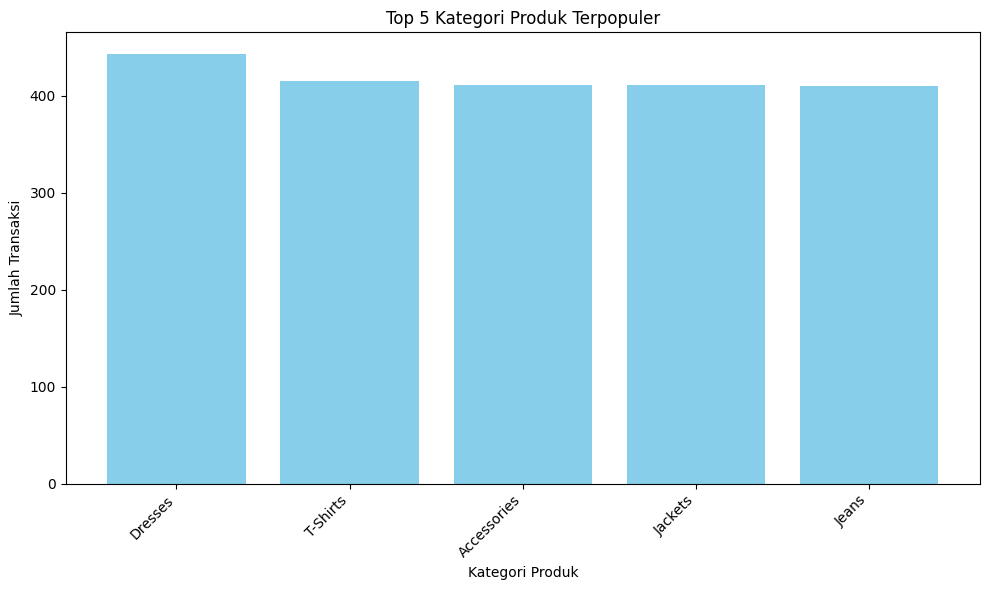

In [538]:
top5produk = df['Product_Category'].value_counts().head(5).sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan

plt.figure(figsize=(10, 6)) # Ukuran
plt.bar(top5produk.index, top5produk.values, color='skyblue') # color warna
plt.xlabel('Kategori Produk') # keterangan X label
plt.ylabel('Jumlah Transaksi') # keterangan y label
plt.title('Top 5 Kategori Produk Terpopuler') # Judul
plt.xticks(rotation=45, ha='right') # rotasi teks
plt.tight_layout()
plt.show()

Insight : Lima kategori produk teratas menunjukkan volume transaksi yang sangat kompetitif dan merata dengan Dresses sebagai pemimpin pasar, sementara selisih jumlah transaksi antara kategori T-Shirts hingga Jeans sangat tipis (di kisaran 400 transaksi).

Tindakan : Fokuskan strategi pemasaran pada kategori Dresses untuk mempertahankan posisi dominannya, serta buat kampanye cross-selling (penjualan silang) antar kategori populer ini guna meningkatkan rata-rata nilai transaksi per pelanggan.

## **Pie Chart**

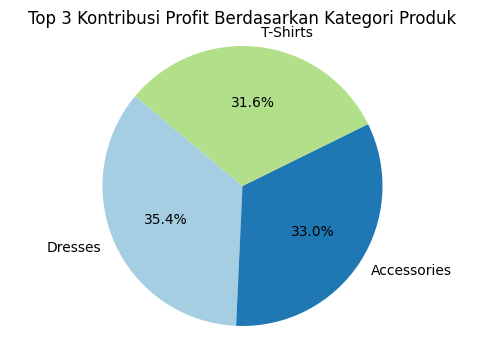

In [539]:
profit = df.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)
top_3_profit = profit.head(3)

plt.figure(figsize=(6, 4)) # Ukuran
top_3_profit.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Top 3 Kontribusi Profit Berdasarkan Kategori Produk') # Judul
plt.ylabel('') # Keterangan Y
plt.axis('equal')
plt.show()

Insight : Kategori Dresses adalah penyumbang keuntungan tertinggi sebesar 35,4%, unggul tipis dibandingkan Accessories dan T-Shirts yang kontribusinya juga cukup signifikan di atas 30%.

Tindakan : Melakukan promosi dan ketersediaan stok lebih pada kategori Dresses karena terbukti paling menguntungkan bagi bisnis ini dibandingkan kategori lainnya.

## **Line Chart**

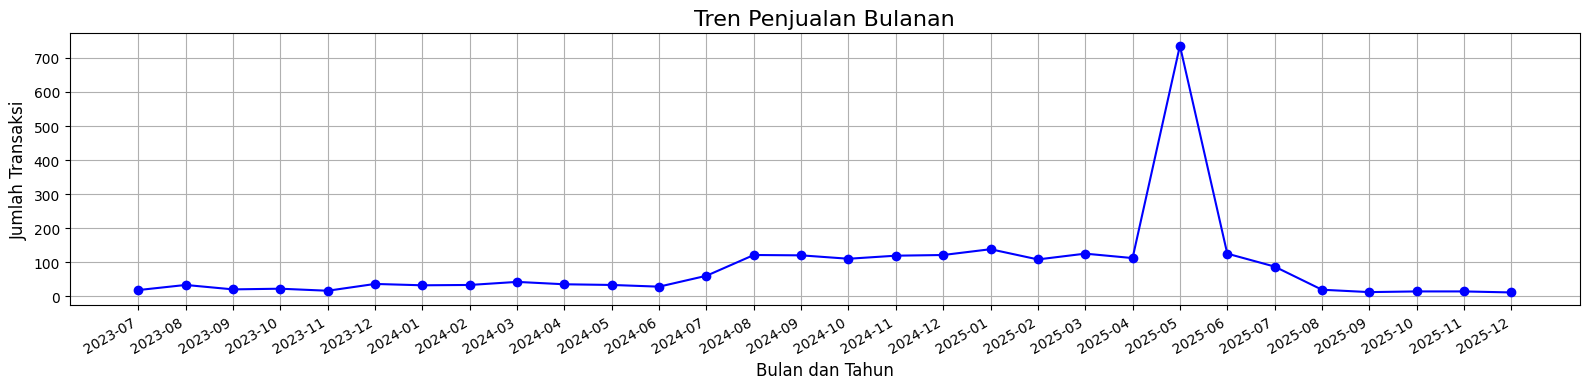

In [540]:
# Pastikan kolom bertipe datetime

# Group by month
tren_penjualan = df.groupby(df['Order_Date'].dt.to_period('M')).size()

plt.figure(figsize=(16, 4)) # Ukuran figure diperbesar untuk kejelasan
plt.plot(tren_penjualan.index.astype(str), tren_penjualan.values, marker='o', color='blue') # Mengubah warna agar berbeda
plt.title('Tren Penjualan Bulanan', fontsize=16) # Judul
plt.xlabel('Bulan dan Tahun', fontsize=12) # X Keterangan
plt.ylabel('Jumlah Transaksi', fontsize=12) # Y Keterangan
plt.grid(True)
plt.gcf().autofmt_xdate() # Otomatis mengatur format dan rotasi di sumbu X
plt.tight_layout()
plt.show()

Insight : Grafik ini menunjukkan naik-turunnya popularitas produk setiap bulan sehingga kita bisa melihat kapan waktu paling ramai pelanggan berbelanja.

Tindakan : Menyiapkan stok barang lebih banyak dan tambah anggaran iklan pada bulan-bulan yang grafiknya meningkat tajam untuk memaksimalkan keuntungan.

## **Histrogram**

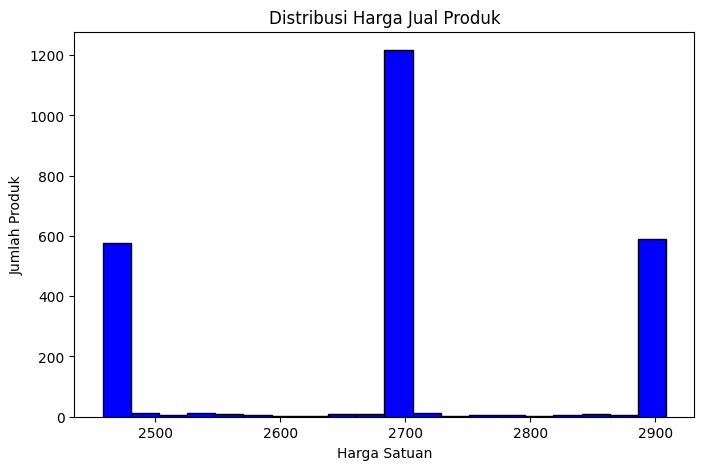

In [541]:
plt.figure(figsize=(8, 5))
plt.hist(df['Unit_Price'], bins=20, color='blue', edgecolor='black')
plt.title('Distribusi Harga Jual Produk')
plt.xlabel('Harga Satuan')
plt.ylabel('Jumlah Produk')
plt.show()

Insight : Harga produk terpusat pada angka 2700, dengan sedikit variasi di harga 2500 dan 2900, sehingga pilihan harga bagi konsumen sangat terbatas pada tiga titik tersebut.

Tindakan : Menambahkan variasi produk di rentang harga (2500–2650) dan (2700-2850) untuk menarik minat pembeli yang memiliki budget menengah.

## **Box Plot**

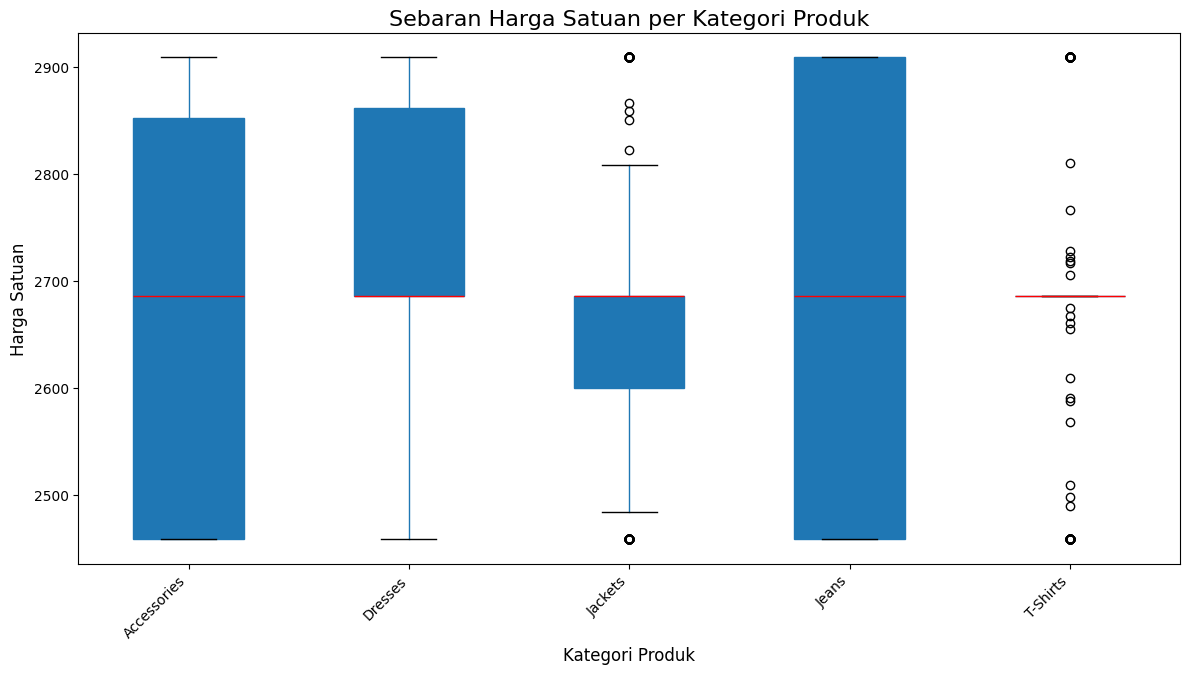

In [542]:
VARIABEL1 = df['Product_Category'].value_counts().head(5).index
VARIABEL2 = df[df['Product_Category'].isin(VARIABEL1)]

plt.figure(figsize=(12, 7)) # Ukuran figure
VARIABEL2.boxplot(column='Unit_Price', by='Product_Category', ax=plt.gca(), grid=False, patch_artist=True, medianprops=dict(color='red'))
plt.title('Sebaran Harga Satuan per Kategori Produk', fontsize=16) # Judul
plt.xlabel('Kategori Produk', fontsize=12) # X Keterangan
plt.ylabel('Harga Satuan', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right')
plt.suptitle('') # Menghilangkan judul default dari boxplot.by
plt.tight_layout()
plt.show()

Insight : Kategori Accessories dan Jeans memiliki rentang harga yang paling bervariasi, sedangkan T-Shirts memiliki harga yang sangat seragam namun memiliki banyak outliers yang menunjukkan adanya produk dengan harga yang jauh berbeda dari rata-rata.

Tindakan : Melakukan evaluasi terhadap produk-produk yang terdapat outlier pada kategori T-Shirts untuk memastikan apakah harga tersebut merupakan kesalahan input data atau memang produk edisi khusus, serta pertahankan variasi harga pada kategori Accessories untuk menjangkau berbagai segmen daya beli konsumen.

## **Scatter Plot**

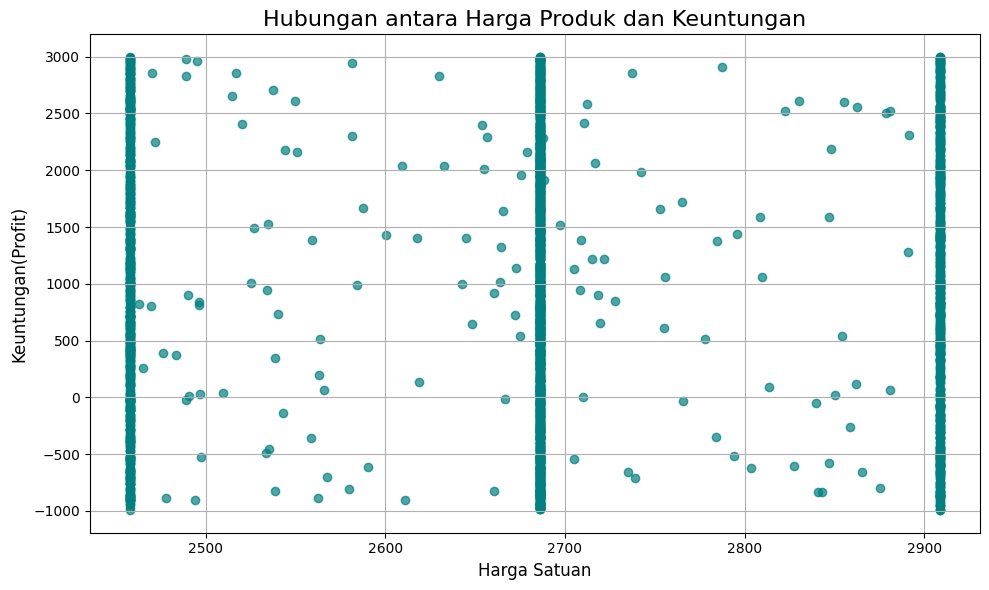

In [543]:
plt.figure(figsize=(10, 6)) # Ukuran
plt.scatter(df['Unit_Price'], df['Profit'], alpha=0.7, color='teal') # Color (Warna)
plt.title('Hubungan antara Harga Produk dan Keuntungan', fontsize=16) # Judul
plt.xlabel('Harga Satuan', fontsize=12) # X Keterangan
plt.ylabel('Keuntungan(Profit)', fontsize=12) # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

Insight : Grafik menunjukkan konsentrasi transaksi yang sangat padat pada tiga titik harga spesifik (sekitar harga 2450, 2700, dan 2900), namun sebaran profitnya sangat lebar mulai dari kerugian signifikan (-1000) hingga keuntungan maksimal (3000), yang menandakan bahwa harga jual tinggi tidak menjamin keuntungan yang stabil.

Tindakan : Identifikasi faktor penyebab kerugian pada transaksi di titik harga populer tersebut (seperti besaran diskon atau biaya pengadaan) dan lakukan standardisasi margin keuntungan agar hubungan relasi data lebih konsisten dan berada di area positif.

## **Heatmap**

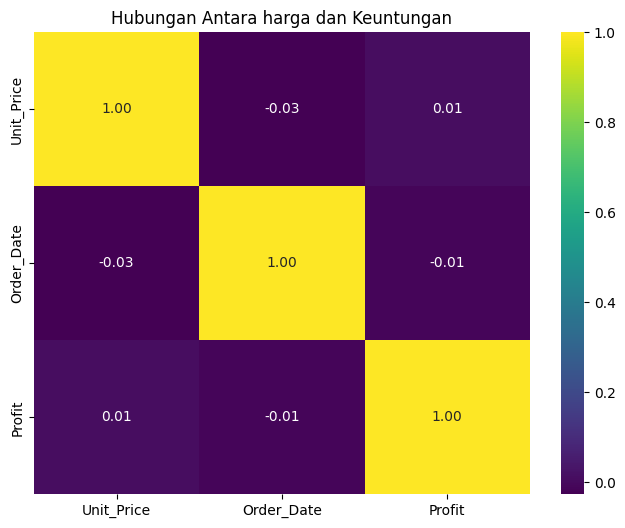

In [544]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['Unit_Price', 'Order_Date', 'Profit']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Hubungan Antara harga dan Keuntungan')
plt.show()

Insight : Nilai korelasi antara Order_Date dengan Profit hampir nol, yaitu -0.Ini menunjukkan bahwa waktu atau tanggal pemesanan sama sekali tidak memengaruhi besar kecilnya keuntungan yang didapat perusahaan secara langsung. Dengan kata lain, keuntungan perusahaan terlihat stabil sepanjang waktu tanpa ada tren musim tertentu yang menonjol.

Tindakan : Karena keuntungan tidak bergantung pada "kapan" barang terjual, sebaiknya perusahaan fokus mencari faktor lain yang lebih berpengaruh, seperti kategori produk atau efisiensi biaya pengiriman. Jangan hanya mengandalkan promo di tanggal-tanggal tertentu (seperti tanggal kembar), tapi pastikan setiap produk yang terjual di hari apa pun memiliki margin keuntungan yang sehat.